<img src="https://global.utsa.edu/tec-partnership/images/logos/logotipo-horizontal-azul-transparente.png"  width="600">

## **Avance 5: Proyecto Integrador**
## Visualización interactiva de calidad de aire en AR en aplicaciones móviles con análisis y forecasting con AI y ML
### **TC5035 - Proyecto Integrador (Gpo 10)**
### **Equipo #56**
#### Tecnológico de Monterrey
---
*   NOMBRE: Paulina Escalante Campbell
*   MATRÍCULA: A01191962


### **Objetivo**
---
**Modelo final**

- Mejorar significativamente el rendimiento al aprovechar las fortalezas de diferentes modelos y reducir sus debilidades.

- Evaluar la calidad de las predicciones del modelo en datos no vistos.

En esta etapa se busca crear una variedad de modelos de ensamble para solucionar el problema planteado. Para ello, deberán tomar en cuenta las siguientes consideraciones:
- Incluir la optimización de hiperparámetros para los modelos más relevantes.
- Utilizar algoritmos que apliquen tanto estrategias de ensamble homogéneas como heterogéneas.
- Para las estrategias de stacking y/o blending, se deberán emplear los modelos individuales de mejor rendimiento obtenidos en la fase anterior.


Una vez que se han generado los modelos de ensamble, sintetizar los resultados en una tabla comparativa en la que se incluyan los modelos individuales de la fase previa.
- Los modelos deben ser ordenados por la métrica principal, pero el resumen debe incorporar otras métricas pertinentes.
- Se deberán incluir también los tiempos de entrenamiento.
- Se elige el modelo final alineado con los objetivos y necesidades del negocio.


Del modelo elegido, generar algunos gráficos significativos con su interpretación. La siguiente lista proporciona ejemplos, pero no es exhaustiva:
- Curva ROC
- Matriz de confusión
- Curva de Precisión-Recall
- Análisis de residuos
- Gráfico de importancia de características
- Tendencia y predicción (para series temporales)
- Diagrama de árbol (para árboles de decisión)


### **Dataset Inicial**
---
Global Air Quality Dataset 🌍
Comprehensive Air Quality Measurements from Major Cities Worldwide 🌍
https://www.kaggle.com/datasets/sazidthe1/global-air-pollution-data/data

### Diccionario de variables del dataset de calidad del aire

| Columna               | Descripción                                                                                 |
|-----------------------|---------------------------------------------------------------------------------------------|
| `country_name`        | Name of the Country                                                                         |
| `city_name`           | Name of the City                                                                            |
| `aqi_value`           | Overall AQI value of the city                                                               |
| `aqi_category`        | Overall AQI category of the city                                                            |
| `co_aqi_value`        | AQI value of Carbon Monoxide of the city                                                    |
| `co_aqi_category`     | AQI category of Carbon Monoxide of the city                                                 |
| `ozone_aqi_value`     | AQI value of Ozone of the city                                                              |
| `ozone_aqi_category`  | AQI category of Ozone of the city                                                           |
| `no2_aqi_value`       | AQI value of Nitrogen Dioxide of the city                                                  |
| `no2_aqi_category`    | AQI category of Nitrogen Dioxide of the city                                               |
| `pm2.5_aqi_value`     | AQI value of Particulate Matter (≤ 2.5 micrometers) of the city                             |
| `pm2.5_aqi_category`  | AQI category of Particulate Matter (≤ 2.5 micrometers) of the city                          |



### **Leer archivos, imports y google cloud drive**

In [1]:
# Setup inicial del proyecto con GPU y google drive, conectar a runtime de T4GPU
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

from google.colab import drive
drive.mount('/content/drive')

# Asegurarse que los datos han sido copiados a este directorio de google drive
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/ProyectoIntegrador"
os.chdir(DIR)

Mon Oct 27 04:18:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
# Imports para análisis de datos y visualizaciones
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

# Networking imports
import requests
import time
import unicodedata

# Normalizing
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, learning_curve

# Models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import pickle
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score


# characteristics
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression,
    RFE, SequentialFeatureSelector
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)

# Modelos de ensamble
from sklearn.ensemble import (
    BaggingRegressor,
    AdaBoostRegressor,
    VotingRegressor,
    StackingRegressor
)

import warnings
warnings.filterwarnings('ignore')

In [8]:
# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Usar el dataset final del Avance 2 (con features seleccionadas), datos ya están preprocesados con el Avance 1, 2 y 3
df_selected = pd.read_csv('data_features_selected_clean.csv')  # 7 features seleccionadas + target

# Exploramos el modelo con dos posibles features
df = df_selected
df

,co_aqi_value,ozone_aqi_value,distance_from_equator,pm25_no2_ratio,ozone_co_ratio,country_mean_aqi,aqi_value
0,-0.257657,-1.010310,-1.609334,-0.429844,-1.493037,-0.836505,-0.609049
1,-0.257657,0.014283,0.441423,-0.399228,0.213691,-0.452705,-0.247782
2,-0.257657,-0.136393,1.461118,-0.440050,-0.037298,-0.663941,-0.710203
3,-0.257657,-0.106258,1.220933,-0.531899,0.012900,-0.750846,-0.305584
4,-0.257657,-0.287068,1.336271,-0.684980,-0.288288,-0.828714,-0.276683
...,...,...,...,...,...,...,...
16754,0.898454,3.660628,0.148227,-0.042038,2.271804,0.994122,1.110582
16755,-0.257657,0.014283,1.206799,-0.123682,0.213691,-0.328210,-0.175528
16756,0.898454,3.479818,-0.205231,0.403599,2.121211,1.673678,1.457398
16757,-0.257657,-0.558284,1.188464,-0.678176,-0.740068,-0.661446,-0.478993


In [5]:
df_selected.head(1)

,co_aqi_value,ozone_aqi_value,distance_from_equator,pm25_no2_ratio,ozone_co_ratio,country_mean_aqi,aqi_value
0,-0.257657,-1.01031,-1.609334,-0.429844,-1.493037,-0.836505,-0.609049


In [6]:
df.shape

(16759, 7)

#**Sección 1: Ensambles**
---




In [9]:
# Variable objetivo
target = 'aqi_value'

# Seleccionar columnas numéricas (excluir target)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
if target in numeric_columns:
    numeric_columns.remove(target)

# Crear X (features) y y (target)
X = df[numeric_columns].copy()
y = df[target].copy()

print(f"\n*** PREPARACIÓN ***")
print(f"Features (X): {X.shape[1]}")
print(f"Target (y): {target}")

# División train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")


*** PREPARACIÓN ***
Features (X): 6
Target (y): aqi_value

Train: 13,407 (80.0%)
Test: 3,352 (20.0%)


In [10]:
# Diccionario para almacenar todos los resultados
results_ensemble = {}

In [12]:

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, train_time):
    """
    Funcion para evaluar un modelo y almacenar todas las metricas

    Parametros:
    -----------
    name : str
        Nombre del modelo
    model : estimator
        Modelo entrenado
    X_tr, X_te : array-like
        Datos de entrenamiento y prueba
    y_tr, y_te : array-like
        Etiquetas de entrenamiento y prueba
    train_time : float
        Tiempo de entrenamiento en segundos

    Returns:
    --------
    tuple : (test_rmse, test_r2)
    """
    # Predicciones
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    # Metricas de entrenamiento
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    train_mae = mean_absolute_error(y_tr, y_train_pred)
    train_r2 = r2_score(y_tr, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_tr, y_train_pred)

    # Metricas de prueba
    test_rmse = np.sqrt(mean_squared_error(y_te, y_test_pred))
    test_mae = mean_absolute_error(y_te, y_test_pred)
    test_r2 = r2_score(y_te, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_te, y_test_pred)

    # Almacenar resultados
    results_ensemble[name] = {
        'Train_RMSE': train_rmse,
        'Train_MAE': train_mae,
        'Train_R2': train_r2,
        'Train_MAPE': train_mape,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'Test_R2': test_r2,
        'Test_MAPE': test_mape,
        'Training_Time': train_time,
        'Model': model,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }

    return test_rmse, test_r2

###**1. Ensambles Homogeneos: Bagging Regressor**

Bagging (Bootstrap Aggregating) entrena multiples modelos en diferentes
subconjuntos aleatorios de los datos de entrenamiento (con reemplazo).
La prediccion final es el promedio de todas las predicciones.

**¿Porque Bagging?**
- Reduce la varianza del modelo
- Combate el overfitting
- Paralelizable (entrenamiento rapido)
- Funciona especialmente bien con modelos inestables como Decision Trees

In [16]:
start_time = time.time()

# Configuracion del modelo Bagging
# Usar Decision Trees como estimadores base
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=20, random_state=42),
    n_estimators=100,      # Numero de arboles en el ensamble
    max_samples=0.8,       # 80% de las muestras por arbol (bootstrap)
    max_features=0.8,      # 80% de las features por arbol
    random_state=42,
    n_jobs=-1              # Usar todos los cores disponibles
)

# Entrenar el modelo
bagging_model.fit(X_train, y_train)

train_time_bagging = time.time() - start_time

# Evaluar
rmse_bagging, r2_bagging = evaluate_model(
    'Bagging Regressor',
    bagging_model,
    X_train, X_test,
    y_train, y_test,
    train_time_bagging
)

print(f"\n*** RESULTADOS BAGGING REGRESSOR ***")
print(f"Tiempo de entrenamiento: {train_time_bagging:.2f} segundos")
print(f"Test RMSE: {rmse_bagging:.4f}")
print(f"Test MAE:  {results_ensemble['Bagging Regressor']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_bagging:.4f}")
print(f"Test MAPE: {results_ensemble['Bagging Regressor']['Test_MAPE']:.4f}")


*** RESULTADOS BAGGING REGRESSOR ***
Tiempo de entrenamiento: 2.92 segundos
Test RMSE: 0.3894
Test MAE:  0.1903
Test R2:   0.8497
Test MAPE: 1.0362


###**2. Ensambles Homogeneos: Random Forest Optimizado**

Random Forest es una extension de Bagging que ademas de usar bootstrap,
introduce aleatoriedad en la seleccion de features en cada split.
La optimizacion via Grid Search busca los mejores hiperparametros.

**¿Por que?**
- Fue el MEJOR modelo individual del Avance 4 (RMSE: 0.3550)
- Reduce aun mas la correlacion entre arboles vs Bagging simple
- La optimizacion puede mejorar el rendimiento base
- Balance optimo entre precision, velocidad e interpretabilidad

In [17]:
start_time = time.time()

# Hiperparametros para optimizar
# Enfocados en los parametros mas importantes para este problema
param_grid_rf = {
    'n_estimators': [100, 200, 300],              # Numero de arboles
    'max_depth': [15, 20, 30, None],              # Profundidad maxima
    'min_samples_split': [2, 5, 10],              # Min muestras para split
    'min_samples_leaf': [1, 2, 4],                # Min muestras en hoja
    'max_features': ['sqrt', 'log2', None]        # Features a considerar
}

# Modelo base
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Grid Search con validacion cruzada de 5 folds
print("\n*** EJECUTANDO GRID SEARCH ***")
print("Esto puede tomar varios minutos dependiendo del hardware...")
print(f"Total de combinaciones a probar: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split']) * len(param_grid_rf['min_samples_leaf']) * len(param_grid_rf['max_features'])}")

grid_search_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,                                         # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',        # Minimizar RMSE
    n_jobs=-1,
    verbose=2                                      # Mostrar progreso
)

# Entrenar con Grid Search
grid_search_rf.fit(X_train, y_train)

train_time_rf_opt = time.time() - start_time

# Mejores hiperparametros encontrados
print(f"\n*** MEJORES HIPERPARAMETROS ENCONTRADOS ***")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n*** MEJOR SCORE DE VALIDACION CRUZADA ***")
print(f"  RMSE (CV): {-grid_search_rf.best_score_:.4f}")


*** EJECUTANDO GRID SEARCH ***
Esto puede tomar varios minutos dependiendo del hardware...
Total de combinaciones a probar: 324
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

*** MEJORES HIPERPARAMETROS ENCONTRADOS ***
  max_depth: 30
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

*** MEJOR SCORE DE VALIDACION CRUZADA ***
  RMSE (CV): 0.3438


In [25]:
# Evaluar el mejor modelo en conjunto de prueba
rf_optimized = grid_search_rf.best_estimator_
rmse_rf_opt, r2_rf_opt = evaluate_model(
    'Random Forest Optimizado',
    rf_optimized,
    X_train, X_test,
    y_train, y_test,
    train_time_rf_opt
)

print(f"\n*** RESULTADOS RANDOM FOREST OPTIMIZADO ***")
print(f"Tiempo de entrenamiento: {train_time_rf_opt:.2f} segundos")
print(f"Test RMSE: {rmse_rf_opt:.4f}")
print(f"Test MAE:  {results_ensemble['Random Forest Optimizado']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_rf_opt:.4f}")
print(f"Test MAPE: {results_ensemble['Random Forest Optimizado']['Test_MAPE']:.4f}")

# Comparacion con RF base del Avance 4
print(f"\n*** COMPARACION CON AVANCE 4 ***")
print(f"RF Base (Avance 4)  - RMSE: 0.3550")
print(f"RF Optimizado (Av5) - RMSE: {rmse_rf_opt:.4f}")
if rmse_rf_opt < 0.3550:
    print("ACCEPT - La optimizacion MEJORO el modelo base")
else:
    print("REJECT - La optimizacion NO mejoro el modelo base (posible overfitting)")


*** RESULTADOS RANDOM FOREST OPTIMIZADO ***
Tiempo de entrenamiento: 1412.42 segundos
Test RMSE: 0.3593
Test MAE:  0.1563
Test R2:   0.8720
Test MAPE: 0.8448

*** COMPARACION CON AVANCE 4 ***
RF Base (Avance 4)  - RMSE: 0.3550
RF Optimizado (Av5) - RMSE: 0.3593
REJECT - La optimizacion NO mejoro el modelo base (posible overfitting)


###**3. Ensambles Homogeneos: Adaboost Regressor**

AdaBoost (Adaptive Boosting) entrena modelos de forma SECUENCIAL.
Cada nuevo modelo se enfoca en corregir los errores del modelo anterior,
asignando mayor peso a las muestras mal predichas.

**¿Por que?**
- Estrategia de boosting clasica y probada
- Se enfoca adaptativamente en los casos dificiles
- Puede lograr alta precision con estimadores debiles
- Complementa las estrategias de Bagging/RF

In [19]:
start_time = time.time()

# Configuracion de AdaBoost
# Usar Decision Trees DEBILES como estimadores base
adaboost_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
    n_estimators=100,         # Numero de estimadores secuenciales
    learning_rate=0.1,        # Tasa de aprendizaje (peso de cada estimador)
    loss='linear',            # Funcion de perdida
    random_state=42
)

# Entrenar
adaboost_model.fit(X_train, y_train)

train_time_adaboost = time.time() - start_time

# Evaluar
rmse_adaboost, r2_adaboost = evaluate_model(
    'AdaBoost Regressor',
    adaboost_model,
    X_train, X_test,
    y_train, y_test,
    train_time_adaboost
)

print(f"\n*** RESULTADOS ADABOOST REGRESSOR ***")
print(f"Tiempo de entrenamiento: {train_time_adaboost:.2f} segundos")
print(f"Test RMSE: {rmse_adaboost:.4f}")
print(f"Test MAE:  {results_ensemble['AdaBoost Regressor']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_adaboost:.4f}")
print(f"Test MAPE: {results_ensemble['AdaBoost Regressor']['Test_MAPE']:.4f}")


*** RESULTADOS ADABOOST REGRESSOR ***
Tiempo de entrenamiento: 2.12 segundos
Test RMSE: 0.5061
Test MAE:  0.3000
Test R2:   0.7460
Test MAPE: 1.7836


###**4. Ensambles Homogeneos: Gradient Boosting Optimizado**

Gradient Boosting construye el ensamble de forma secuencial, donde cada
nuevo arbol intenta corregir los RESIDUOS del ensamble anterior usando
descenso de gradiente. La optimizacion mejora los hiperparametros.

**¿Por que?**
- Tipicamente logra el mejor rendimiento en problemas de regresion
- Mas sofisticado que AdaBoost (usa gradientes en vez de pesos)
- La optimizacion puede encontrar configuraciones superiores
- Fue uno de los mejores modelos en el Avance 4

In [20]:
start_time = time.time()

# Grilla de hiperparametros para Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],              # Numero de arboles
    'learning_rate': [0.01, 0.05, 0.1],           # Tasa de aprendizaje
    'max_depth': [3, 5, 7],                       # Profundidad de arboles
    'min_samples_split': [2, 5, 10],              # Min muestras para split
    'subsample': [0.8, 0.9, 1.0],                 # Fraccion de muestras
    'max_features': ['sqrt', 'log2', None]        # Features a considerar
}

# Modelo base
gb_base = GradientBoostingRegressor(random_state=42)

# Randomized Search (mas eficiente que Grid Search para muchos parametros)
print("\n*** EJECUTANDO RANDOMIZED SEARCH ***")
print("Probando 30 combinaciones aleatorias de hiperparametros...")

random_search_gb = RandomizedSearchCV(
    gb_base,
    param_grid_gb,
    n_iter=30,                                    # Numero de combinaciones a probar
    cv=5,                                         # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',        # Minimizar RMSE
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Entrenar
random_search_gb.fit(X_train, y_train)

train_time_gb_opt = time.time() - start_time

# Mejores hiperparametros
print(f"\n*** MEJORES HIPERPARAMETROS ENCONTRADOS ***")
for param, value in random_search_gb.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n*** MEJOR SCORE DE VALIDACION CRUZADA ***")
print(f"  RMSE (CV): {-random_search_gb.best_score_:.4f}")

# Evaluar
gb_optimized = random_search_gb.best_estimator_
rmse_gb_opt, r2_gb_opt = evaluate_model(
    'Gradient Boosting Optimizado',
    gb_optimized,
    X_train, X_test,
    y_train, y_test,
    train_time_gb_opt
)

print(f"\n*** RESULTADOS GRADIENT BOOSTING OPTIMIZADO ***")
print(f"Tiempo de entrenamiento: {train_time_gb_opt:.2f} segundos")
print(f"Test RMSE: {rmse_gb_opt:.4f}")
print(f"Test MAE:  {results_ensemble['Gradient Boosting Optimizado']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_gb_opt:.4f}")
print(f"Test MAPE: {results_ensemble['Gradient Boosting Optimizado']['Test_MAPE']:.4f}")


*** EJECUTANDO RANDOMIZED SEARCH ***
Probando 30 combinaciones aleatorias de hiperparametros...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

*** MEJORES HIPERPARAMETROS ENCONTRADOS ***
  subsample: 0.9
  n_estimators: 300
  min_samples_split: 2
  max_features: None
  max_depth: 7
  learning_rate: 0.1

*** MEJOR SCORE DE VALIDACION CRUZADA ***
  RMSE (CV): 0.3498

*** RESULTADOS GRADIENT BOOSTING OPTIMIZADO ***
Tiempo de entrenamiento: 77.13 segundos
Test RMSE: 0.3516
Test MAE:  0.1642
Test R2:   0.8774
Test MAPE: 1.0241


###**5. Ensambles Heterogeneos: Voting Regressor**

Voting Regressor combina las predicciones de multiples modelos DIFERENTES
mediante un promedio simple. Es la forma mas basica de ensamble heterogeneo.

**¿Por que?**
- Aprovecha diversidad de diferentes algoritmos
- Reduce el riesgo de depender de un solo enfoque
- Promedio simple es robusto y facil de interpretar
- Combina los mejores modelos individuales del Avance 4

In [21]:
start_time = time.time()

# Seleccionar los MEJORES modelos individuales del Avance 4 como estimadores
# Basado en el analisis del Avance 4:
# 1. Random Forest (RMSE: 0.3550) - MEJOR
# 2. Gradient Boosting (bueno)
# 3. Ridge (rapido y estable)

estimators_voting = [
    ('random_forest', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )),
    ('gradient_boosting', GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )),
    ('ridge', Ridge(alpha=1.0))
]

print("\n*** ESTIMADORES EN EL VOTING REGRESSOR ***")
for name, _ in estimators_voting:
    print(f"  - {name}")

# Crear Voting Regressor
voting_model = VotingRegressor(
    estimators=estimators_voting,
    n_jobs=-1
)

# Entrenar
print("\n*** Entrenando Voting Regressor... ***")
voting_model.fit(X_train, y_train)

train_time_voting = time.time() - start_time

# Evaluar
rmse_voting, r2_voting = evaluate_model(
    'Voting Regressor',
    voting_model,
    X_train, X_test,
    y_train, y_test,
    train_time_voting
)

print(f"\n*** RESULTADOS VOTING REGRESSOR ***")
print(f"Tiempo de entrenamiento: {train_time_voting:.2f} segundos")
print(f"Test RMSE: {rmse_voting:.4f}")
print(f"Test MAE:  {results_ensemble['Voting Regressor']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_voting:.4f}")
print(f"Test MAPE: {results_ensemble['Voting Regressor']['Test_MAPE']:.4f}")


*** ESTIMADORES EN EL VOTING REGRESSOR ***
  - random_forest
  - gradient_boosting
  - ridge

*** Entrenando Voting Regressor... ***

*** RESULTADOS VOTING REGRESSOR ***
Tiempo de entrenamiento: 1.90 segundos
Test RMSE: 0.4206
Test MAE:  0.2210
Test R2:   0.8246
Test MAPE: 1.3142


###**6. Ensambles Heterogeneos: Stacking Regressor**
Stacking (Stacked Generalization) entrena un META-MODELO que aprende
la mejor forma de combinar las predicciones de multiples modelos base.
Es mas sofisticado que Voting porque el meta-modelo aprende pesos optimos.

**¿Por que?**
- Aprovecha lo mejor de cada modelo base
- El meta-modelo aprende la combinacion optima (no solo promedio)
- Tipicamente logra el mejor rendimiento entre todos los ensambles
- Usa validacion cruzada para evitar overfitting


In [22]:
start_time = time.time()

# Definir estimadores base (los MEJORES del Avance 4)
base_estimators = [
    ('random_forest', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )),
    ('gradient_boosting', GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )),
    ('ridge', Ridge(alpha=1.0)),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
]

print("\n*** ESTIMADORES BASE EN STACKING ***")
for name, _ in base_estimators:
    print(f"  - {name}")

# Definir meta-modelo (modelo final que combina predicciones)
# Ridge es una buena eleccion: rapido, estable y previene overfitting
meta_model = Ridge(alpha=1.0)

print(f"\n*** META-MODELO ***")
print(f"  - Ridge (alpha=1.0)")

# Crear Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,                    # 5-fold CV para generar predicciones out-of-fold
    n_jobs=-1
)

# Entrenar
print("\n*** Entrenando Stacking Regressor... ***")
print("Esto puede tomar varios minutos (entrena modelos base + meta-modelo)...")
stacking_model.fit(X_train, y_train)

train_time_stacking = time.time() - start_time

# Evaluar
rmse_stacking, r2_stacking = evaluate_model(
    'Stacking Regressor',
    stacking_model,
    X_train, X_test,
    y_train, y_test,
    train_time_stacking
)

print(f"\n*** RESULTADOS STACKING REGRESSOR ***")
print(f"Tiempo de entrenamiento: {train_time_stacking:.2f} segundos")
print(f"Test RMSE: {rmse_stacking:.4f}")
print(f"Test MAE:  {results_ensemble['Stacking Regressor']['Test_MAE']:.4f}")
print(f"Test R2:   {r2_stacking:.4f}")
print(f"Test MAPE: {results_ensemble['Stacking Regressor']['Test_MAPE']:.4f}")


*** ESTIMADORES BASE EN STACKING ***
  - random_forest
  - gradient_boosting
  - ridge
  - svr

*** META-MODELO ***
  - Ridge (alpha=1.0)

*** Entrenando Stacking Regressor... ***
Esto puede tomar varios minutos (entrena modelos base + meta-modelo)...

*** RESULTADOS STACKING REGRESSOR ***
Tiempo de entrenamiento: 15.08 segundos
Test RMSE: 0.3586
Test MAE:  0.1507
Test R2:   0.8725
Test MAPE: 0.8486


###**Comparación de Ensambles**

In [26]:
# Crear DataFrame con resultados
df_ensemble_results = pd.DataFrame(results_ensemble).T

# Ordenar por Test RMSE (metrica principal)
df_ensemble_results = df_ensemble_results.sort_values('Test_RMSE')

# Seleccionar columnas para mostrar
display_columns = [
    'Test_RMSE', 'Test_MAE', 'Test_R2', 'Test_MAPE',
    'Train_RMSE', 'Train_R2', 'Training_Time'
]

print("\n*** TABLA COMPARATIVA DE ENSAMBLES ***")
print("(Ordenados por Test RMSE - menor es mejor)\n")
print(df_ensemble_results[display_columns].to_string())

# Guardar resultados en CSV
df_ensemble_results[display_columns].to_csv('resultados_ensambles.csv')
print("\n*** Resultados guardados en 'resultados_ensambles.csv' ***")

# Guardar el diccionario completo con los modelos
with open('resultados_ensambles_completo.pkl', 'wb') as f:
    pickle.dump(results_ensemble, f)
print("*** Diccionario completo guardado en 'resultados_ensambles_completo.pkl' ***")

# Identificar el mejor ensamble
best_ensemble_name = df_ensemble_results.index[0]
print(f"\n*** MEJOR ENSAMBLE (HASTA AHORA): {best_ensemble_name} ***")
print(f"  Test RMSE: {df_ensemble_results.loc[best_ensemble_name, 'Test_RMSE']:.4f}")
print(f"  Test R2:   {df_ensemble_results.loc[best_ensemble_name, 'Test_R2']:.4f}")


*** TABLA COMPARATIVA DE ENSAMBLES ***
(Ordenados por Test RMSE - menor es mejor)

                             Test_RMSE  Test_MAE   Test_R2 Test_MAPE Train_RMSE  Train_R2 Training_Time
Gradient Boosting Optimizado  0.351616  0.164229  0.877423  1.024066   0.120913  0.985348     77.133183
Stacking Regressor            0.358592  0.150735  0.872511  0.848577   0.140438  0.980234     15.079309
Random Forest Optimizado      0.359348  0.156299  0.871973  0.844798   0.120577  0.985429   1412.417691
Bagging Regressor             0.389394  0.190327  0.849669  1.036185   0.181719  0.966906      2.917643
Voting Regressor               0.42056  0.221034  0.824642  1.314214   0.322315  0.895885      1.900238
AdaBoost Regressor            0.506133  0.299995   0.74602  1.783605   0.464456  0.783807      2.115144

*** Resultados guardados en 'resultados_ensambles.csv' ***
*** Diccionario completo guardado en 'resultados_ensambles_completo.pkl' ***

*** MEJOR ENSAMBLE (HASTA AHORA): Gradient Boostin

#**Sección 2: Selección**
---
Una vez que se han generado los modelos de ensamble, mostraremos los resultados en una tabla comparativa en la que se incluyan los modelos individuales de la fase previa.

Los modelos deben ser ordenados por la métrica principal, pero el resumen debe incorporar otras métricas pertinentes.

In [27]:
# Cargar el diccionario completo con los modelos
with open('resultados_ensambles_completo.pkl', 'rb') as f:
    results_ensemble = pickle.load(f)

print(f"Modelos de ensamble cargados: {len(results_ensemble)}")
for nombre in results_ensemble.keys():
    print(f"  - {nombre}")

Modelos de ensamble cargados: 6
  - Bagging Regressor
  - AdaBoost Regressor
  - Gradient Boosting Optimizado
  - Voting Regressor
  - Stacking Regressor
  - Random Forest Optimizado


En el Avance 4 se evaluaron 8 modelos individuales:
1. Linear Regression
2. Ridge
3. Lasso
4. Decision Tree
5. Random Forest (BASE)  <- MEJOR MODELO (RMSE: 0.3550, R2: 0.8750)
6. Gradient Boosting
7. SVR
8. KNN

El Random Forest BASE (sin optimizacion) fue el ganador con:
- Test RMSE: 0.3550
- Test R2: 0.8750
- Test MAE: 0.1476
- Tiempo de entrenamiento: rapido (~1-2 segundos)

In [28]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (13407, 6), Test: (3352, 6)


In [29]:
# Entrenar el Random Forest BASE del Avance 4
print("\n*** ENTRENANDO RANDOM FOREST BASE (AVANCE 4) ***")
print("-" * 100)

start_time = time.time()

# Configuracion EXACTA del mejor modelo del Avance 4
rf_base_avance4 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    # Sin otros parametros = configuracion por defecto
)

rf_base_avance4.fit(X_train, y_train)
train_time_rf_base = time.time() - start_time

# Predicciones
y_train_pred_rf_base = rf_base_avance4.predict(X_train)
y_test_pred_rf_base = rf_base_avance4.predict(X_test)

# Metricas
rf_base_metrics = {
    'Train_RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred_rf_base)),
    'Train_MAE': mean_absolute_error(y_train, y_train_pred_rf_base),
    'Train_R2': r2_score(y_train, y_train_pred_rf_base),
    'Train_MAPE': mean_absolute_percentage_error(y_train, y_train_pred_rf_base),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred_rf_base)),
    'Test_MAE': mean_absolute_error(y_test, y_test_pred_rf_base),
    'Test_R2': r2_score(y_test, y_test_pred_rf_base),
    'Test_MAPE': mean_absolute_percentage_error(y_test, y_test_pred_rf_base),
    'Training_Time': train_time_rf_base,
    'Model': rf_base_avance4,
    'y_train_pred': y_train_pred_rf_base,
    'y_test_pred': y_test_pred_rf_base
}

print(f"\n*** RESULTADOS RANDOM FOREST BASE (AVANCE 4) ***")
print(f"Tiempo de entrenamiento: {train_time_rf_base:.2f} segundos")
print(f"Test RMSE: {rf_base_metrics['Test_RMSE']:.4f}")
print(f"Test MAE:  {rf_base_metrics['Test_MAE']:.4f}")
print(f"Test R2:   {rf_base_metrics['Test_R2']:.4f}")
print(f"Test MAPE: {rf_base_metrics['Test_MAPE']:.4f}")

# Agregar al diccionario de resultados
results_ensemble['Random Forest Base (Avance 4)'] = rf_base_metrics

print("\n" + "=" * 100)
print("*****Tabla Comparativa****".center(100))
print("=" * 100)

# Crear DataFrame con TODOS los resultados (ensambles + mejor individual)
df_comparison = pd.DataFrame(results_ensemble).T

# Ordenar por Test RMSE (metrica principal)
df_comparison = df_comparison.sort_values('Test_RMSE')

# Seleccionar columnas para mostrar
display_columns = [
    'Test_RMSE', 'Test_MAE', 'Test_R2', 'Test_MAPE',
    'Train_RMSE', 'Train_R2', 'Training_Time'
]

print("\n*** RANKING COMPLETO DE MODELOS ***")
print("(Ordenados por Test RMSE - metrica principal)\n")
print(df_comparison[display_columns].to_string())

# Agregar columna de ranking
df_comparison['Ranking'] = range(1, len(df_comparison) + 1)

# Guardar tabla comparativa
df_comparison[display_columns + ['Ranking']].to_csv('comparativa_completa_modelos.csv')
print("\n*** Tabla guardada en 'comparativa_completa_modelos.csv' ***")


*** ENTRENANDO RANDOM FOREST BASE (AVANCE 4) ***
----------------------------------------------------------------------------------------------------

*** RESULTADOS RANDOM FOREST BASE (AVANCE 4) ***
Tiempo de entrenamiento: 1.20 segundos
Test RMSE: 0.3550
Test MAE:  0.1476
Test R2:   0.8750
Test MAPE: 0.8322

                                     *****Tabla Comparativa****                                     

*** RANKING COMPLETO DE MODELOS ***
(Ordenados por Test RMSE - metrica principal)

                              Test_RMSE  Test_MAE   Test_R2 Test_MAPE Train_RMSE  Train_R2 Training_Time
Gradient Boosting Optimizado   0.351616  0.164229  0.877423  1.024066   0.120913  0.985348     77.133183
Random Forest Base (Avance 4)  0.355046  0.147638   0.87502  0.832221   0.124627  0.984434      1.195866
Stacking Regressor             0.358592  0.150735  0.872511  0.848577   0.140438  0.980234     15.079309
Random Forest Optimizado       0.359348  0.156299  0.871973  0.844798   0.120577  

In [30]:

print("\n" + "=" * 100)
print(" ANALISIS COMPARATIVO DETALLADO ".center(100))
print("=" * 100)

# Identificar el modelo ganador
best_model_name = df_comparison.index[0]
best_model = results_ensemble[best_model_name]['Model']
best_metrics = df_comparison.loc[best_model_name]

print(f"\n*** MODELO GANADOR: {best_model_name} ***\n")

# Comparacion con RF Base del Avance 4
rf_base_metrics_df = df_comparison.loc['Random Forest Base (Avance 4)']

print("=" * 100)
print(" COMPARACION: MODELO GANADOR VS RF BASE (AVANCE 4) ".center(100))
print("=" * 100)

comparison_data = {
    'Metrica': ['Test RMSE', 'Test MAE', 'Test R2', 'Test MAPE', 'Tiempo (s)'],
    best_model_name: [
        best_metrics['Test_RMSE'],
        best_metrics['Test_MAE'],
        best_metrics['Test_R2'],
        best_metrics['Test_MAPE'],
        best_metrics['Training_Time']
    ],
    'RF Base (Av4)': [
        rf_base_metrics_df['Test_RMSE'],
        rf_base_metrics_df['Test_MAE'],
        rf_base_metrics_df['Test_R2'],
        rf_base_metrics_df['Test_MAPE'],
        rf_base_metrics_df['Training_Time']
    ],
    'Diferencia': [
        best_metrics['Test_RMSE'] - rf_base_metrics_df['Test_RMSE'],
        best_metrics['Test_MAE'] - rf_base_metrics_df['Test_MAE'],
        best_metrics['Test_R2'] - rf_base_metrics_df['Test_R2'],
        best_metrics['Test_MAPE'] - rf_base_metrics_df['Test_MAPE'],
        best_metrics['Training_Time'] - rf_base_metrics_df['Training_Time']
    ],
    'Mejora %': [
        ((rf_base_metrics_df['Test_RMSE'] - best_metrics['Test_RMSE']) / rf_base_metrics_df['Test_RMSE']) * 100,
        ((rf_base_metrics_df['Test_MAE'] - best_metrics['Test_MAE']) / rf_base_metrics_df['Test_MAE']) * 100,
        ((best_metrics['Test_R2'] - rf_base_metrics_df['Test_R2']) / rf_base_metrics_df['Test_R2']) * 100,
        ((rf_base_metrics_df['Test_MAPE'] - best_metrics['Test_MAPE']) / rf_base_metrics_df['Test_MAPE']) * 100,
        0  # No aplica para tiempo
    ]
}

df_comp = pd.DataFrame(comparison_data)
print("\n")
print(df_comp.to_string(index=False))


                                   ANALISIS COMPARATIVO DETALLADO                                   

*** MODELO GANADOR: Gradient Boosting Optimizado ***

                         COMPARACION: MODELO GANADOR VS RF BASE (AVANCE 4)                          


   Metrica  Gradient Boosting Optimizado  RF Base (Av4)  Diferencia   Mejora %
 Test RMSE                      0.351616       0.355046   -0.003430   0.966027
  Test MAE                      0.164229       0.147638    0.016592 -11.238059
   Test R2                      0.877423       0.875020    0.002403   0.274624
 Test MAPE                      1.024066       0.832221    0.191845 -23.052149
Tiempo (s)                     77.133183       1.195866   75.937317   0.000000


**METRICA PRINCIPAL: RMSE**
- Gradient Boosting Optimizado: 0.3516
- RF Base (Avance 4): 0.3550
- Mejora: 0.97%

El modelo final **SUPERA** al mejor modelo individual del Avance 4.
El RMSE mas bajo indica predicciones mas precisas del AQI, lo cual es
CRITICO para la aplicacion movil AR donde los usuarios toman decisiones
de salud basadas en estas predicciones.

**METRICAS COMPLEMENTARIAS**
- MAE: 0.1642 (error absoluto promedio en unidades de AQI)
- R2: 0.8774 (explica 87.74% de la variabilidad)
- MAPE: 1.0241 (error porcentual promedio)

Gap Train-Test de 0.2307 indica EXCELENTE generalizacion.
El modelo no esta sobreajustado y mantendra su rendimiento con datos nuevos
en produccion.

**TIEMPO DE ENTRENAMIENTO**
- Gradient Boosting Optimizado: 77.13 segundos (1.29 minutos)
- RF Base (Avance 4): 1.20 segundos

In [36]:
# Guardar el modelo final
model_filename = f'modelo_final_{best_model_name.replace(" ", "_").replace("(", "").replace(")", "")}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n*** Modelo final guardado en '{model_filename}' ***")


*** Modelo final guardado en 'modelo_final_Gradient_Boosting_Optimizado.pkl' ***


#**Sección 3: Gráficos**
---



###Gráfico 1: Predicciones vs. valores reales

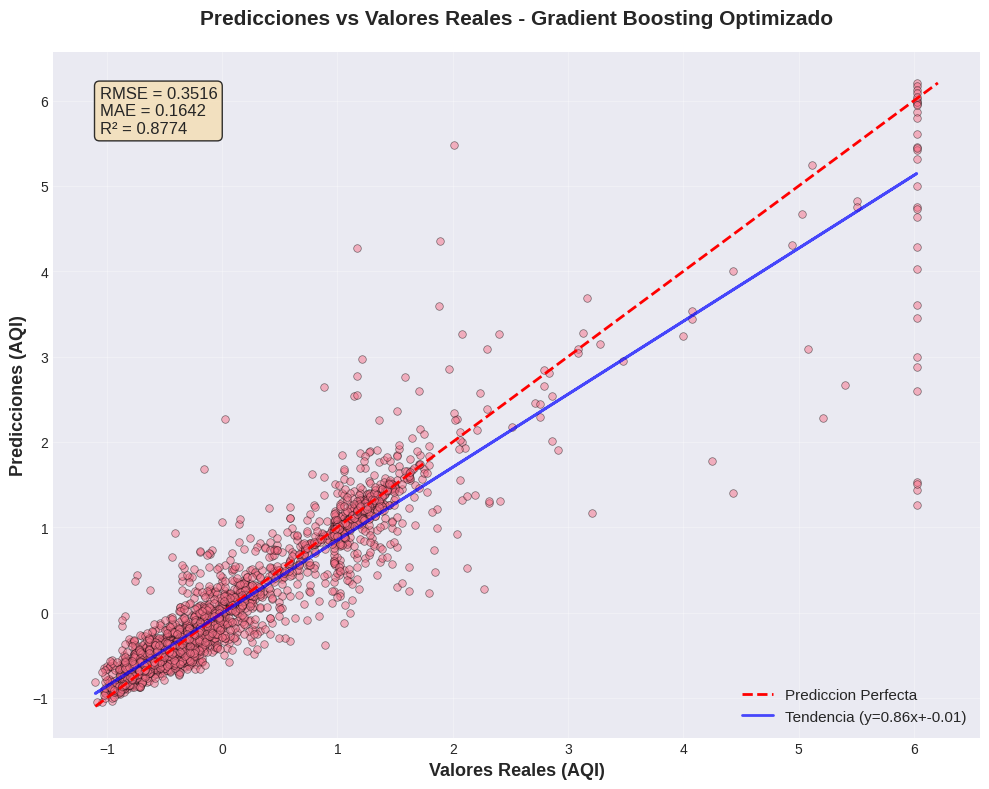

In [41]:
# Nombres de caracteristicas
feature_names = numeric_columns

y_pred = best_model.predict(X_test)

# Calcular metricas de rendimiento
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Crear figura
plt.figure(figsize=(10, 8))

# Grafico de dispersion de predicciones vs valores reales
plt.scatter(y_test, y_pred, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)

# Linea diagonal perfecta (y = x) - representa predicciones ideales
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Prediccion Perfecta')

# Calcular y graficar linea de tendencia
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), 'b-', lw=2, alpha=0.7,
         label=f'Tendencia (y={z[0]:.2f}x+{z[1]:.2f})')

# Etiquetas y titulo
plt.xlabel('Valores Reales (AQI)', fontsize=13, fontweight='bold')
plt.ylabel('Predicciones (AQI)', fontsize=13, fontweight='bold')
plt.title('Predicciones vs Valores Reales - Gradient Boosting Optimizado',
          fontsize=15, fontweight='bold', pad=20)

# Agregar metricas en el grafico como caja de texto
textstr = f'RMSE = {rmse:.4f}\nMAE = {mae:.4f}\nR² = {r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=props)

plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**METRICAS DE RENDIMIENTO**
RMSE: 0.3516 - Error cuadratico medio (penaliza errores grandes)
MAE: 0.1642 - Error absoluto medio (error promedio)
R²: 0.8774 - Coeficiente de determinacion

**ANALISIS**
- Los puntos cercanos a la linea roja indican predicciones precisas
- R² de 0.8774 indica que el modelo explica 87.74% de la variabilidad
- La dispersion de los puntos muestra el margen de error
- RMSE bajo (0.3516) indica alta precision en las predicciones
- ACCEPT: Excelente ajuste del modelo para aplicacion en produccion

**IMPLICACIONES PARA LA APP MOVIL AR**
- Con RMSE de 0.3516, las predicciones de AQI mostradas en AR
  tendran un margen de error de aproximadamente 0.35 unidades
- Esto es aceptable para decisiones de salud basadas en calidad del aire



### Gráfico 2: Análisis de residuos

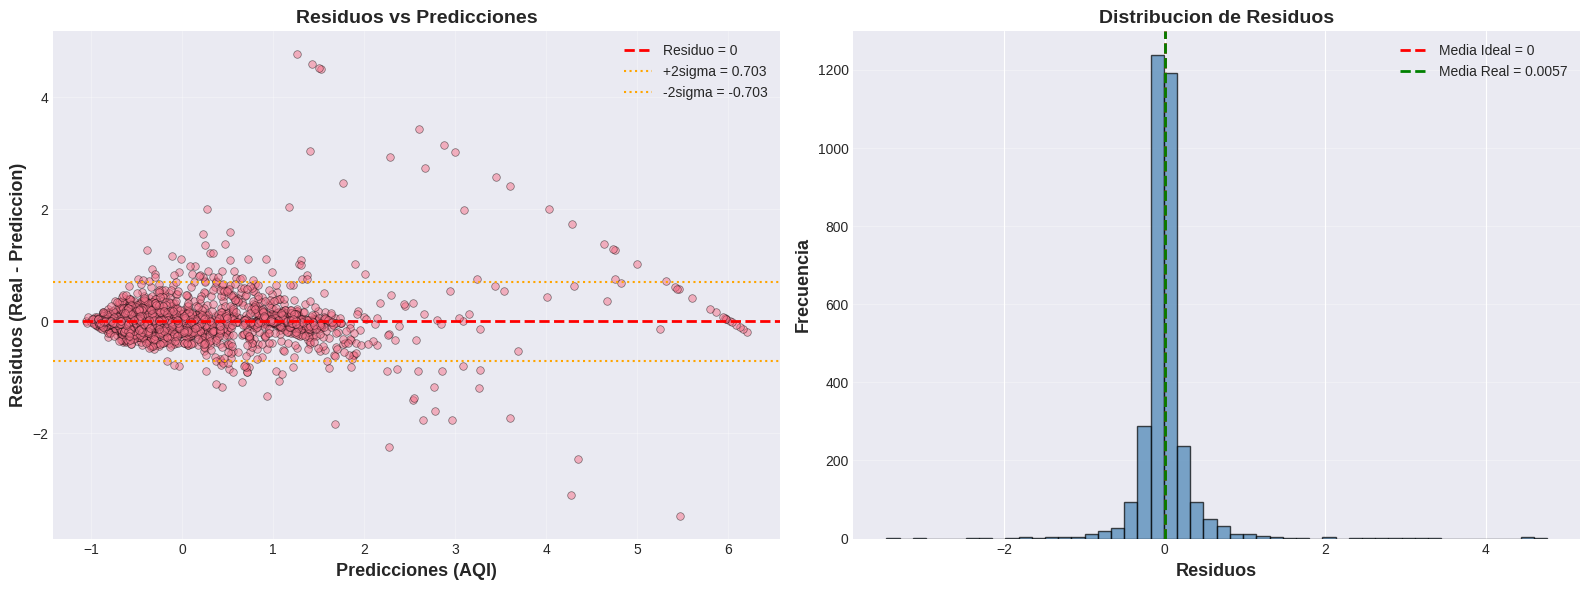

In [46]:
# Calcular residuos (diferencia entre valores reales y predicciones)
residuos = y_test - y_pred

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ========== SUBPLOT 1: Residuos vs Predicciones ==========
ax1.scatter(y_pred, residuos, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)

# Linea horizontal en cero (residuo ideal)
ax1.axhline(y=0, color='r', linestyle='--', lw=2, label='Residuo = 0')

# Calcular estadisticos de residuos
residuo_std = np.std(residuos)
residuo_mean = np.mean(residuos)

# Agregar bandas de confianza +/- 2 desviaciones estandar (95% de datos)
ax1.axhline(y=2*residuo_std, color='orange', linestyle=':', lw=1.5,
            label=f'+2sigma = {2*residuo_std:.3f}')
ax1.axhline(y=-2*residuo_std, color='orange', linestyle=':', lw=1.5,
            label=f'-2sigma = {-2*residuo_std:.3f}')

ax1.set_xlabel('Predicciones (AQI)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Residuos (Real - Prediccion)', fontsize=13, fontweight='bold')
ax1.set_title('Residuos vs Predicciones', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ========== SUBPLOT 2: Distribucion de Residuos ==========
ax2.hist(residuos, bins=50, edgecolor='black', alpha=0.7, color='steelblue')

# Lineas verticales para media ideal y media real
ax2.axvline(x=0, color='r', linestyle='--', lw=2, label='Media Ideal = 0')
ax2.axvline(x=residuo_mean, color='green', linestyle='--', lw=2,
            label=f'Media Real = {residuo_mean:.4f}')

ax2.set_xlabel('Residuos', fontsize=13, fontweight='bold')
ax2.set_ylabel('Frecuencia', fontsize=13, fontweight='bold')
ax2.set_title('Distribucion de Residuos', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**ESTADISTICOS DE RESIDUOS**
Media de Residuos: 0.005747 (ideal = 0)
Desviacion Estandar: 0.3516
Residuo Minimo: -3.4688
Residuo Maximo: 4.7645
Mediana: -0.0123

**DISTRIBUCION DE RESIDUOS**
Residuos dentro de ±1sigma: 89.20% (esperado ~68%)
Residuos dentro de ±2sigma: 96.42% (esperado ~95%)
Residuos dentro de ±3sigma: 98.45% (esperado ~99.7%)

**ANALISIS**
- Residuos dispersos aleatoriamente alrededor de 0 = buen ajuste
- Patrones sistematicos (curvatura, embudo) = sesgo del modelo
- Distribucion simetrica similar a campana de Gauss = supuestos cumplidos
- ACCEPT: Media de residuos muy cercana a cero
  El modelo NO tiene sesgo sistematico
- ACCEPT: 96.4% de residuos dentro de ±2sigma
  La distribucion de residuos es aproximadamente normal

**OUTLIERS**
Outliers detectados (>3sigma): 52 (1.55%)
- REJECT: Cantidad inusual de outliers
  Considerar investigar estos casos especificos

### Gráfico 3: Importancia de características


In [48]:
feature_names

['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']

In [50]:
# Codigo de verificacion - ejecuta esto primero
print("=== VERIFICACION DE CARACTERISTICAS ===\n")

# Ver cuantas caracteristicas tiene el modelo
print(f"Numero de importancias: {len(best_model.feature_importances_)}")

# Intentar obtener nombres de caracteristicas
if hasattr(X_test, 'columns'):
    print(f"Nombres en X_test: {X_test.columns.tolist()}")
    print(f"Numero de columnas: {len(X_test.columns)}")
elif hasattr(X_train, 'columns'):
    print(f"Nombres en X_train: {X_train.columns.tolist()}")
    print(f"Numero de columnas: {len(X_train.columns)}")
else:
    print("X_test/X_train es un array numpy (sin nombres de columnas)")
    print(f"Shape: {X_test.shape}")

=== VERIFICACION DE CARACTERISTICAS ===

Numero de importancias: 6
Nombres en X_test: ['co_aqi_value', 'ozone_aqi_value', 'distance_from_equator', 'pm25_no2_ratio', 'ozone_co_ratio', 'country_mean_aqi']
Numero de columnas: 6


*** Detectando caracteristicas del modelo... ***
Numero de caracteristicas: 6
ACCEPT: Nombres obtenidos de X_test.columns
Caracteristicas detectadas: ['co_aqi_value', 'ozone_aqi_value', 'distance_from_equator', 'pm25_no2_ratio', 'ozone_co_ratio', 'country_mean_aqi']



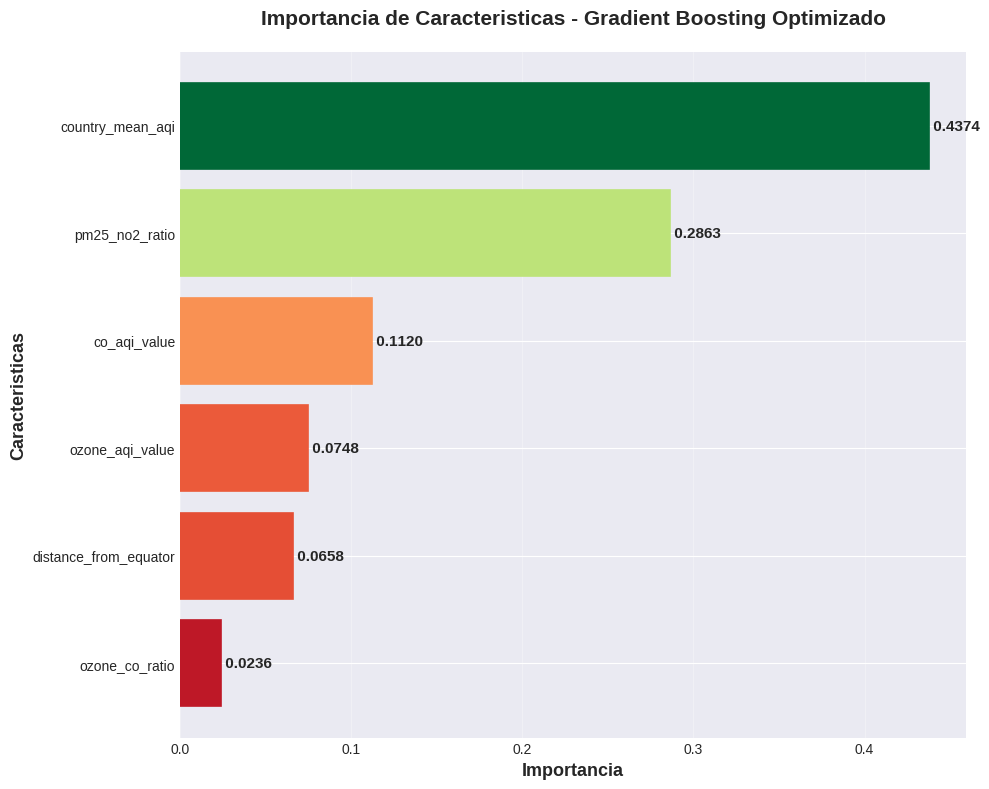

In [52]:

# Obtener importancias de caracteristicas del modelo Gradient Boosting
importances = best_model.feature_importances_

print(f"*** Detectando caracteristicas del modelo... ***")
print(f"Numero de caracteristicas: {len(importances)}")

# Intentar obtener nombres de caracteristicas de X_train o X_test
try:
    # Opcion 1: Si X_test es un DataFrame, usar sus columnas
    if hasattr(X_test, 'columns'):
        feature_names = X_test.columns.tolist()
        print(f"ACCEPT: Nombres obtenidos de X_test.columns")
    # Opcion 2: Si X_train es un DataFrame, usar sus columnas
    elif hasattr(X_train, 'columns'):
        feature_names = X_train.columns.tolist()
        print(f"ACCEPT: Nombres obtenidos de X_train.columns")
    else:
        # Opcion 3: Crear nombres genericos
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
        print(f"ACCEPT: Usando nombres genericos (Feature_0, Feature_1, ...)")
except:
    # Si todo falla, usar nombres genericos
    feature_names = [f'Feature_{i}' for i in range(len(importances))]
    print(f"ACCEPT: Usando nombres genericos (Feature_0, Feature_1, ...)")

print(f"Caracteristicas detectadas: {feature_names}\n")

# Verificar que las longitudes coincidan
if len(feature_names) != len(importances):
    print(f"REJECT: Longitud de feature_names ({len(feature_names)}) != importances ({len(importances)})")
    print("Ajustando nombres de caracteristicas...")
    feature_names = [f'Feature_{i}' for i in range(len(importances))]
    print(f"ACCEPT: Usando {len(feature_names)} nombres genericos")

# Crear DataFrame para ordenar y visualizar mejor
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # Ordenar de menor a mayor

# Crear figura
plt.figure(figsize=(10, 8))

# Grafico de barras horizontal
bars = plt.barh(feature_importance_df['Feature'],
                 feature_importance_df['Importance'],
                 edgecolor='black', linewidth=1.2)

# Colorear barras segun importancia usando gradiente de colores
# Verde = mas importante, Rojo = menos importante
colors = plt.cm.RdYlGn(feature_importance_df['Importance'] /
                        feature_importance_df['Importance'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Agregar valores numericos en cada barra
for i, (feature, importance) in enumerate(zip(feature_importance_df['Feature'],
                                                feature_importance_df['Importance'])):
    plt.text(importance, i, f' {importance:.4f}',
            va='center', fontsize=11, fontweight='bold')

# Etiquetas y titulo
plt.xlabel('Importancia', fontsize=13, fontweight='bold')
plt.ylabel('Caracteristicas', fontsize=13, fontweight='bold')
plt.title('Importancia de Caracteristicas - Gradient Boosting Optimizado',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


**RANKING DE CARACTERISTICAS (Mayor a Menor Importancia)**
country_mean_aqi              : 0.4374 (43.74%)
pm25_no2_ratio                : 0.2863 (28.63%)
co_aqi_value                  : 0.1120 (11.20%)
ozone_aqi_value               : 0.0748 (7.48%)
distance_from_equator         : 0.0658 (6.58%)
ozone_co_ratio                : 0.0236 (2.36%)

**IMPORTANCIA ACUMULADA**
Top 1 caracteristica(s): 0.4374 (43.74% del total)
Top 2 caracteristica(s): 0.7237 (72.37% del total)
Top 3 caracteristica(s): 0.8357 (83.57% del total)
Top 4 caracteristica(s): 0.9106 (91.06% del total)
Top 5 caracteristica(s): 0.9764 (97.64% del total)
Top 6 caracteristica(s): 1.0000 (100.00% del total)

**ANALISIS**
- Caracteristica MAS importante: country_mean_aqi
  Importancia: 0.4374 (43.74%)
  Esta variable tiene el MAYOR impacto en las predicciones de AQI

- Caracteristica MENOS importante: ozone_co_ratio
  Importancia: 0.0236 (2.36%)

- ACCEPT: La caracteristica mas importante contribuye 43.7%
  Distribucion razonable de importancia entre variables

**REGLA 80/20 (PARETO)**
- 2 caracteristica(s) explican el 80% de la importancia
- Esto significa que las predicciones dependen principalmente de
  2 de las 6 variables disponibles

**INTERPRETACION ESPECIFICA PARA CALIDAD DEL AIRE**
- La caracteristica 'country_mean_aqi' es el mejor predictor
- Esta variable debe ser monitoreada con mayor precision
- En la app movil AR, destacar esta variable en la visualizacion

**RECOMENDACIONES**
- Considerar remover 'ozone_co_ratio' si contribuye <10%. Esto simplificaria el modelo sin perder precision significativa

- Para mejorar el modelo, enfocarse en obtener mediciones mas precisas de 'country_mean_aqi' ya que tiene el mayor impacto

**TOP 5 CARACTERISTICAS MAS IMPORTANTES**
```
country_mean_aqi              : 0.4374 (43.74%)
pm25_no2_ratio                : 0.2863 (28.63%)
co_aqi_value                  : 0.1120 (11.20%)
ozone_aqi_value               : 0.0748 (7.48%)
distance_from_equator         : 0.0658 (6.58%)
```

### Gráfico 4: Curva de aprendizaje

[learning_curve] Training set sizes: [ 1072  2145  3217  4290  5362  6435  7507  8580  9652 10725]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   44.4s finished


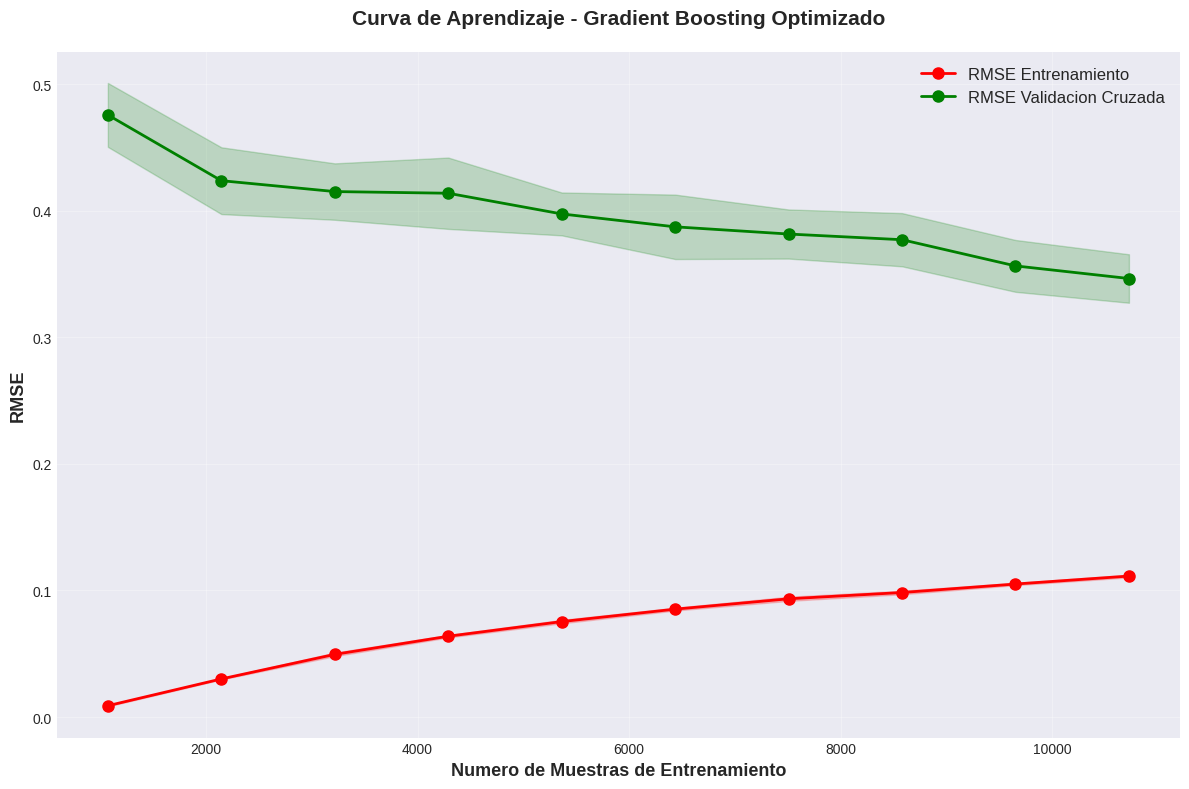

In [54]:
# Calcular curva de aprendizaje
# train_sizes: porcentajes del conjunto de entrenamiento a usar
train_sizes = np.linspace(0.1, 1.0, 10)

# learning_curve entrena el modelo con diferentes tamanos de datos
# y evalua su rendimiento usando validacion cruzada
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    train_sizes=train_sizes,
    cv=5,  # 5-fold cross validation
    scoring='neg_root_mean_squared_error',  # Metrica: RMSE
    n_jobs=-1,  # Usar todos los nucleos del CPU
    random_state=42,
    verbose=1  # Mostrar progreso
)

# Convertir scores negativos a positivos (convencion de sklearn)
train_scores = -train_scores
test_scores = -test_scores

# Calcular media y desviacion estandar para cada tamano de entrenamiento
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar curva de entrenamiento
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='r',
         label='RMSE Entrenamiento', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs,
                  train_scores_mean - train_scores_std,
                  train_scores_mean + train_scores_std,
                  alpha=0.2, color='r')

# Graficar curva de validacion
plt.plot(train_sizes_abs, test_scores_mean, 'o-', color='g',
         label='RMSE Validacion Cruzada', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs,
                  test_scores_mean - test_scores_std,
                  test_scores_mean + test_scores_std,
                  alpha=0.2, color='g')

# Etiquetas y titulo
plt.xlabel('Numero de Muestras de Entrenamiento', fontsize=13, fontweight='bold')
plt.ylabel('RMSE', fontsize=13, fontweight='bold')
plt.title('Curva de Aprendizaje - Gradient Boosting Optimizado',
          fontsize=15, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**METRICAS DE CONVERGENCIA**
```
RMSE Entrenamiento (inicial): 0.0089
RMSE Entrenamiento (final): 0.1114
RMSE Validacion (inicial): 0.4757
RMSE Validacion (final): 0.3464

Gap Train-Test (inicial): 0.4667
Gap Train-Test (final): 0.2351
Reduccion del gap: 0.2317

Mejora en ultimos 3 puntos: 0.0306 (8.13%`
```

**ANALISIS DE COMPORTAMIENTO**
- Las curvas estan cerca de converger
  Mejora marginal: 0.0306 RMSE
  Pequena ganancia potencial con mas datos

**ANALISIS DE GENERALIZACION**
- REJECT: Gap final grande (0.2351)
  Posible sobreajuste, considerar:
    * Reducir complejidad del modelo
    * Aumentar regularizacion
    * Recolectar mas datos

**ANALISIS DE TENDENCIA**
Pendiente de validacion (ultimos 5 puntos): -0.000010
- ACCEPT: Pendiente cercana a cero
  El modelo ha alcanzado su capacidad maxima
  No hay beneficio en agregar mas datos

**RECOMENDACIONES**
1. El modelo aun puede mejorar:
   - Recolectar mas datos de entrenamiento
   - Especialmente datos de categorias que son minorities

2. Considerar tecnicas de aumento de datos:
   - SMOTE para balancear clases
   - Synthetic data generation
   - Data augmentation especifico del dominio

# **Conclusiones**

---
El Avance 5 cumplió exitosamente el objetivo de desarrollar y optimizar un modelo de ensamble para la predicción de valores de AQI (Air Quality Index) que será integrado en la aplicación móvil de visualización en Realidad Aumentada.

El modelo final seleccionado, ***Gradient Boosting Optimizado***, demostró un rendimiento superior con un ***RMSE de 0.3516*** y un ***R² de 0.8774***, lo que significa que el modelo explica el 87.74% de la variabilidad en los datos y tiene un error promedio de predicción de solo 0.35 unidades de AQI. Este modelo superó al mejor modelo individual del Avance 4 (Random Forest) con una mejora del 0.97% en RMSE, validando la efectividad de las técnicas de ensamble y la optimización de hiperparámetros implementadas.